In [1]:
import numpy as np
from src.image_analyzer import ImageAnalyzer
from src.numbering import ClassicalNumbering
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
images_folder_path = r"Z:\victor\initial_distribution\Apr21_2026_095430img_push_img"
n_reps = 200
numbering = ClassicalNumbering(n_reps=n_reps)
analyzer_images = ImageAnalyzer(calibration_file="calibration20260309.json",
images_folder_path=images_folder_path,
numbering=numbering
)

# analyzer_images.analyze_images()
# data_images = analyzer_images.data
# atoms = pd.DataFrame(
#     data_images["atoms_in_image"].tolist(),
#     index=data_images.index,
#     columns=[f"atom_{i}" for i in range(100)],
# )
# data_images = pd.concat([data_images, atoms], axis=1).drop(columns=["atoms_in_image"])
# data_images.to_parquet("initial_distribution.parquet")
data_images = pd.read_parquet("initial_distribution.parquet")

images analyzed with data taken on:  2026-03-09
expecting an atom array of size:  10 x 10
the ROIs are of size:  5 x 5
images to analyze are in:  Z:\victor\initial_distribution\Apr21_2026_095430img_push_img


In [5]:
data_images.head()

,total_atoms,image_index,repetition_index,atom_0,atom_1,atom_2,atom_3,atom_4,atom_5,atom_6,...,atom_90,atom_91,atom_92,atom_93,atom_94,atom_95,atom_96,atom_97,atom_98,atom_99
0,65,0,0,1,0,0,1,1,1,1,...,1,1,0,1,1,0,0,0,1,0
1,5,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,64,0,1,1,0,1,1,1,0,1,...,1,1,0,1,0,0,1,1,1,1
3,6,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,62,0,2,0,1,1,1,0,1,1,...,1,1,1,1,1,1,0,1,1,1


In [7]:
means = data_images.groupby("image_index")["total_atoms"].mean()
print(means)
means[1] / means[0]

image_index
0    60.95
1     4.66
Name: total_atoms, dtype: float64


np.float64(0.07645611156685808)

In [8]:
# df: columns image_index, repetition_index, atom_0 .. atom_99
ATOM_COLS = [f"atom_{i}" for i in range(100)]
GRID = (10, 10)  # atom_0 = top-left → row 0, col 0

d0 = data_images[data_images["image_index"] == 0].set_index("repetition_index")[ATOM_COLS]
d1 = data_images[data_images["image_index"] == 1].set_index("repetition_index")[ATOM_COLS]
both = d0.add_suffix("_0").join(d1.add_suffix("_1"), how="inner")
per_rep = pd.DataFrame({
    c: ((both[f"{c}_0"] == 1) & (both[f"{c}_1"] == 1)).sum(axis=0)
       / (both[f"{c}_0"] == 1).sum(axis=0)
    for c in ATOM_COLS
}, index=[0])  # one row; or loop reps if you split both by rep

# mean across repetitions (nanmean ignores reps where that atom never appeared as "first")
mean_survival = per_rep.mean(axis=0, skipna=True)
mean_survival.mean(), mean_survival.std() / np.sqrt(n_reps)

(np.float64(0.07563705392719922), np.float64(0.001696869540752857))

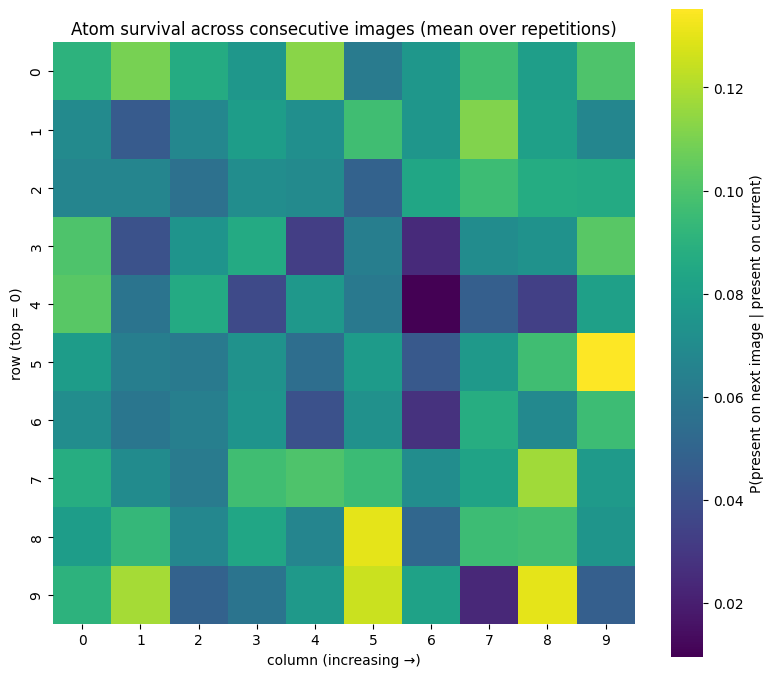

In [9]:
heat = mean_survival.to_numpy().reshape(GRID)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    heat,
    vmin=np.min(heat),
    vmax=np.max(heat),
    cmap="viridis",
    square=True,
    cbar_kws={"label": "P(present on next image | present on current)"},
    ax=ax,
)
ax.set_title("Atom survival across consecutive images (mean over repetitions)")
ax.set_xlabel("column (increasing →)")
ax.set_ylabel("row (top = 0)")
plt.tight_layout()
plt.show()